## Model Training

Import all libraries

In [70]:
import pandas as pd
pd.set_option('display.max_columns', 100)
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.model_selection import GridSearchCV
from sklearn import metrics

from xgboost import XGBRegressor
from xgboost import plot_importance
from sklearn.inspection import permutation_importance


load dataset

In [71]:
df = pd.read_csv('final_df.csv')
df.head()

,base_price,distance_km,days_until_departure,trip_duration_minutes,number_of_stops,departure_hour,arrival_hour,is_weekend_departure,origin_YVR,origin_YYC,origin_YYZ,destination_YVR,destination_YYC,destination_YYZ,Name_airline_Air North Yukon's Airline,Name_airline_Air Transat,Name_airline_Central Mountain Air LTD,Name_airline_Pacific Coastal Airlines Limited,Name_airline_Porter Airlines Canada Limited,Name_airline_WestJet,day_of_week_departure_Monday,day_of_week_departure_Saturday,day_of_week_departure_Sunday,day_of_week_departure_Thursday,day_of_week_departure_Tuesday,day_of_week_departure_Wednesday,departure_time_period_Early Morning,departure_time_period_Evening,departure_time_period_Late Evening,departure_time_period_Morning,departure_time_period_Night,arrival_time_period_Early Morning,arrival_time_period_Evening,arrival_time_period_Late Evening,arrival_time_period_Morning,arrival_time_period_Night,season_Spring,season_Summer,season_Winter
0,216,363,1,81,0,5,7,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0
1,216,363,1,75,0,6,8,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0
2,216,363,1,75,0,10,11,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0
3,216,363,1,75,0,15,16,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,216,363,1,75,0,18,20,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0


In [72]:
df.shape

(43157, 39)

### XGBoost Model

In [73]:
# input variables
X = df.drop('base_price', axis=1)

# target variable
y = df['base_price']

Train-test split: 70-30

In [74]:
# split the dataset
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [75]:
# Define xgb as XGBRegressor with regression objective
xgb = XGBRegressor(random_state=0)  # Regression loss

# Define parameters (keep as is, but increase n_estimators for better fit)
cv_params = {
    'max_depth': [4, 6],
    'min_child_weight': [3, 5],
    'learning_rate': [0.1, 0.2, 0.3],
    'n_estimators': [50, 100, 150],  # Increased from [5,10,15]
    'subsample': [0.7],
    'colsample_bytree': [0.7]
}

# Construct GridSearch
xgb_cv = GridSearchCV(xgb, cv_params)

# %%time
# fit the GridSearch model to training data
xgb_cv = xgb_cv.fit(x_train,y_train)
print("Best params:", xgb_cv.best_params_)

Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.3, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 150, 'subsample': 0.7}


In [76]:
# Apply your model to predict on your test data. Call this output "y_pred"
best_model = xgb_cv.best_estimator_
test_pred = best_model.predict(x_test)
train_pred = best_model.predict(x_train)

print(f'Training MAE: {mean_absolute_error(y_train, train_pred):.2f}')
print(f'Training R2: {r2_score(y_train, train_pred):.3f}')

print(f'Test MAE: {mean_absolute_error(y_test, test_pred):.2f}')
print(f'Test R2: {r2_score(y_test, test_pred):.3f}')

Training MAE: 20.90
Training R2: 0.893
Test MAE: 25.98
Test R2: 0.812


<Figure size 1200x1200 with 0 Axes>

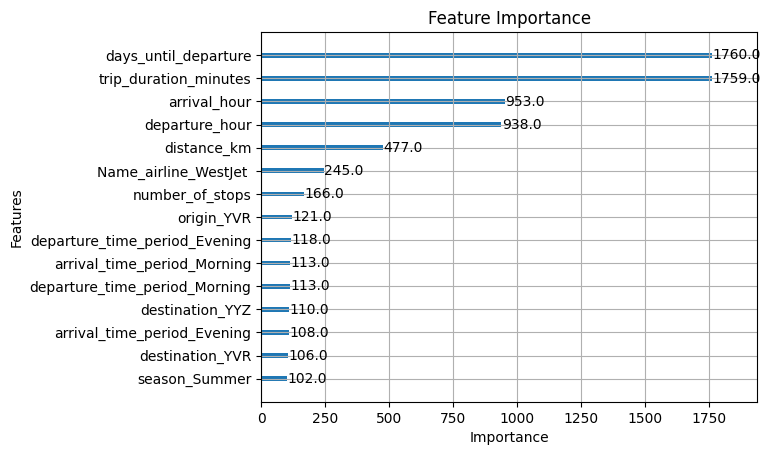

In [77]:
# Plot the relative feature importance of the predictor variables in your model.
plt.figure(figsize=(12, 12))
plot_importance(xgb_cv.best_estimator_, max_num_features=15)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

### Random Forest

In [78]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42, n_jobs = -1)


# Define parameters (keep as is, but increase n_estimators for better fit)
cv_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt', 0.5]
}

# Construct GridSearch
rf_cv = GridSearchCV(rf, cv_params, cv=5,
                     scoring='r2', refit=True, n_jobs=-1)
rf_cv.fit(x_train, y_train)
print("Best params:", rf_cv.best_params_)

Best params: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}


In [79]:
best_rf = rf_cv.best_estimator_
test_pred = best_rf.predict(x_test)
train_pred = best_rf.predict(x_train)

print(f'Training MAE: {mean_absolute_error(y_train, train_pred):.2f}')
print(f'Training R2: {r2_score(y_train, train_pred):.3f}')

print(f'Test MAE: {mean_absolute_error(y_test, test_pred):.2f}')
print(f'Test R2: {r2_score(y_test, test_pred):.3f}')

Training MAE: 19.10
Training R2: 0.870
Test MAE: 22.93
Test R2: 0.811


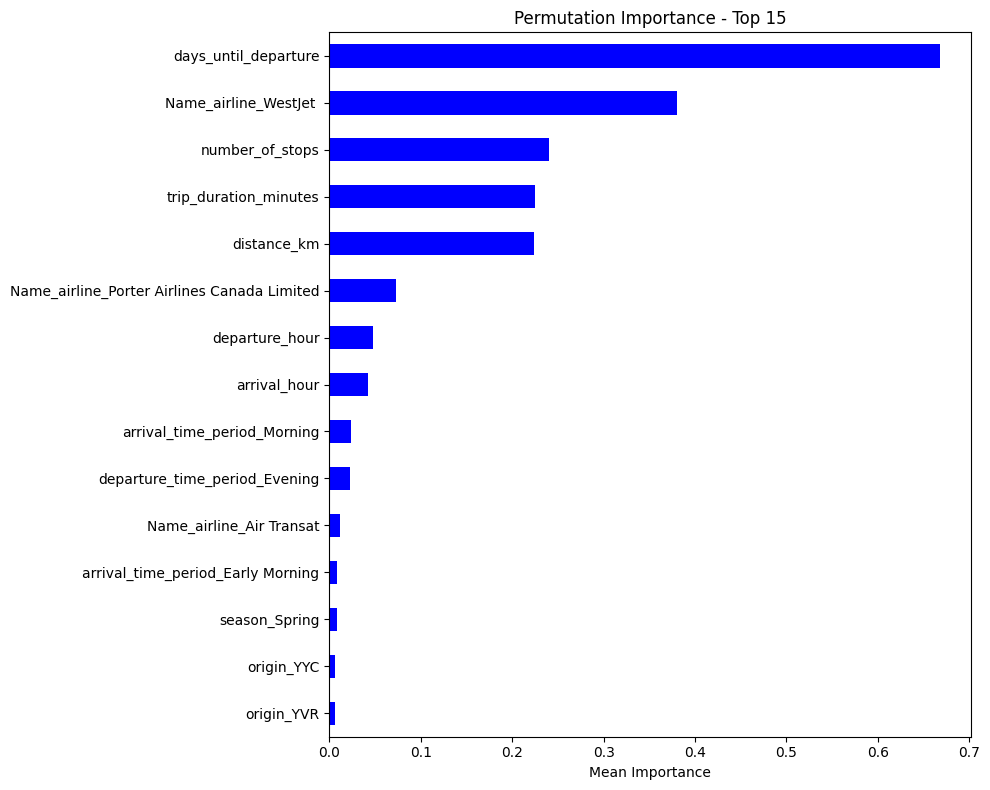

In [80]:
perm_imp = permutation_importance(best_rf, x_test, y_test, n_repeats=10, random_state=42)

perm_series = pd.Series(perm_imp.importances_mean, index=X.columns).sort_values(ascending=True)
perm_series.tail(15).plot(kind='barh', figsize=(10, 8), color='blue')
plt.title('Permutation Importance - Top 15')
plt.xlabel('Mean Importance')
plt.tight_layout()
plt.show()

### Model Comparison

In [81]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

results = pd.DataFrame(columns = ['Model', 'Train MAE', 'Train R2', 'Test MAE', 'Test R2'])

def add_results(model_name, model_object):
    train_pred = model_object.predict(x_train)
    test_pred = model_object.predict(x_test)
    train_mae = mean_absolute_error(y_train, train_pred)
    train_r2 = r2_score(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    test_r2 = r2_score(y_test, test_pred)

    result_dict = {
        'Model': model_name,
        'Train MAE': train_mae,
        'Train R2': train_r2,
        'Test MAE': test_mae,
        'Test R2': test_r2
    }

    table = pd.DataFrame(result_dict, index=[0])

    return table

results = pd.concat([results, add_results('XGBoost', best_model)], ignore_index=True)
results = pd.concat([results, add_results('Random Forest', best_rf)], ignore_index=True)
results

,Model,Train MAE,Train R2,Test MAE,Test R2
0,XGBoost,20.902754,0.893310,25.982632,0.812116
1,Random Forest,19.099129,0.870341,22.930164,0.810871
